In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training data:", x_train.shape)
print("Testing data:", x_test.shape)

Training data: (60000, 28, 28)
Testing data: (10000, 28, 28)


In [2]:
# Normalize pixel values from 0-255 to 0-1
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Add channel dimension
# Original: (60000, 28, 28)
# New:      (60000, 28, 28, 1)

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

In [3]:
model = tf.keras.Sequential([

    # Input: 28 x 28 grayscale image
    tf.keras.layers.Input(shape=(28, 28, 1)),

    # First convolution layer
    tf.keras.layers.Conv2D(
        32,
        (3, 3),
        activation="relu"
    ),

    # Reduce image size
    tf.keras.layers.MaxPooling2D(
        (2, 2)
    ),

    # Second convolution layer
    tf.keras.layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    # Reduce image size again
    tf.keras.layers.MaxPooling2D(
        (2, 2)
    ),

    # Convert feature maps to 1D
    tf.keras.layers.Flatten(),

    # Fully connected layer
    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),

    # Output layer: 10 digits
    tf.keras.layers.Dense(
        10,
        activation="softmax"
    )
])


In [4]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [6]:
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)


Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9503 - loss: 0.1650 - val_accuracy: 0.9835 - val_loss: 0.0556
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.9852 - loss: 0.0483 - val_accuracy: 0.9900 - val_loss: 0.0359
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9901 - loss: 0.0317 - val_accuracy: 0.9907 - val_loss: 0.0327
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9928 - loss: 0.0237 - val_accuracy: 0.9905 - val_loss: 0.0389
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.9942 - loss: 0.0182 - val_accuracy: 0.9898 - val_loss: 0.0393


In [7]:
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test
)

print("\nTest Loss:", test_loss)
print("Test Accuracy:", test_accuracy)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9898 - loss: 0.0307

Test Loss: 0.03067462518811226
Test Accuracy: 0.989799976348877


In [8]:

predictions = model.predict(x_test)

# Get digit having highest probability
predicted_digits = np.argmax(predictions, axis=1)

print("\nPredicted digits:")
print(predicted_digits[:10])

print("\nActual digits:")
print(y_test[:10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Predicted digits:
[7 2 1 0 4 1 4 9 5 9]

Actual digits:
[7 2 1 0 4 1 4 9 5 9]


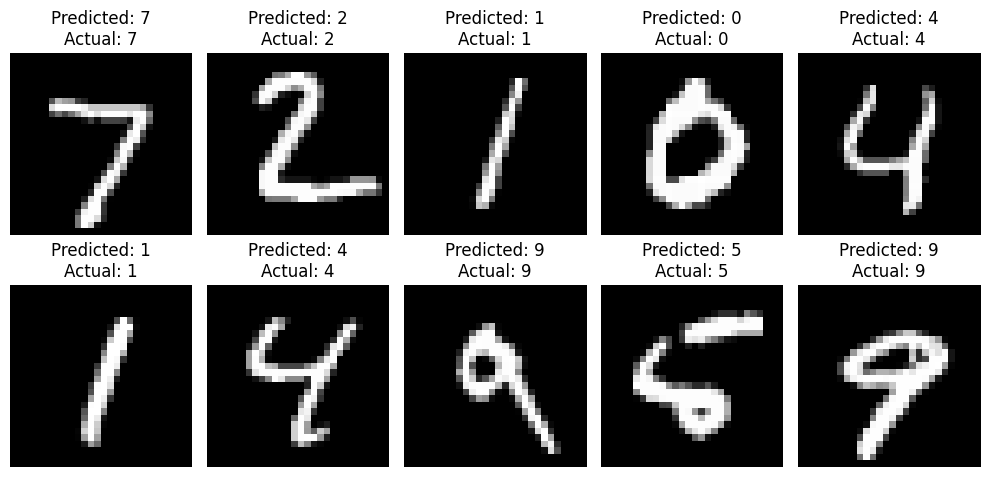

In [9]:
plt.figure(figsize=(10, 5))

for i in range(10):

    plt.subplot(2, 5, i + 1)

    plt.imshow(
        x_test[i].reshape(28, 28),
        cmap="gray"
    )

    plt.title(
        "Predicted: " + str(predicted_digits[i]) +
        "\nActual: " + str(y_test[i])
    )

    plt.axis("off")

plt.tight_layout()
plt.show()


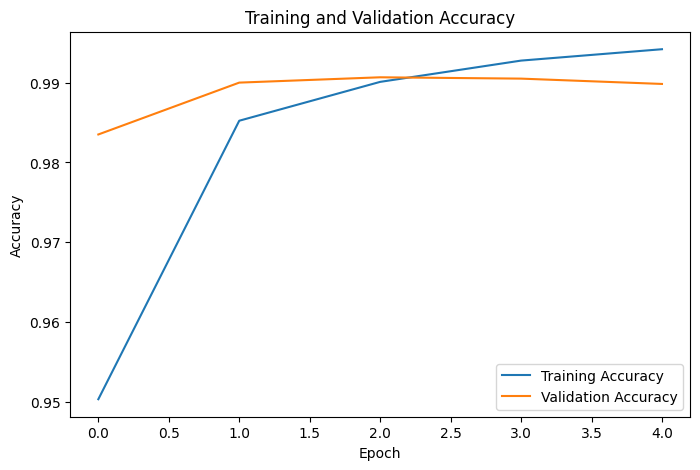

In [10]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")

plt.legend()
plt.show()


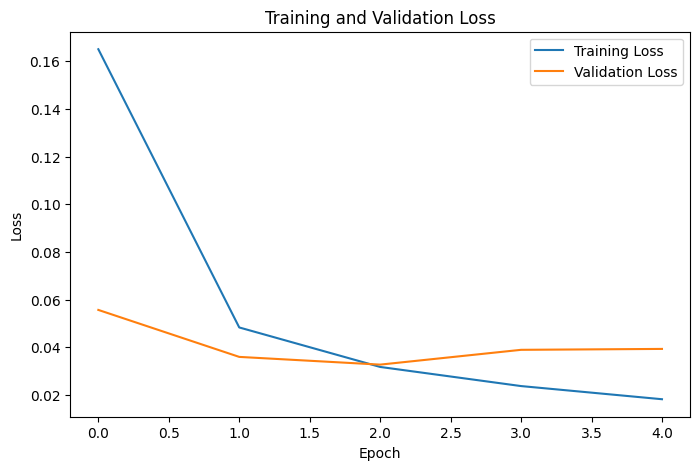

In [11]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.show()